# Notebook 06 — Risk Modeling: Logistic Regression

## Human-to-Gorilla Zoonotic Disease Transmission Risk Analysis

---

### Purpose
Build a **logistic regression risk model** predicting the probability that a gorilla
illness event is tourism-attributed, given:

| Feature | Type | Rationale |
|---------|------|----------|
| Age category | Categorical | Susceptibility varies by age |
| Season | Categorical | Controls for background illness |
| Gorilla group | Categorical | Controls for visit frequency |
| Tourist volume | Numeric | Exposure pressure |
| Symptomatic tourist count | Numeric | Direct exposure metric |
| Masking compliance rate | Numeric | Mitigation factor |
| Altitude | Numeric | Proxy for remoteness / access |
| Immunocompromised status | Binary | Individual vulnerability |

### Model Outputs
- Coefficient table with odds ratios and 95% CIs
- ROC-AUC score
- Feature importance
- Policy scenario simulations

### Critical Limitation
> This model predicts **linkage probability**, not causal attribution. It quantifies
> statistical association, not mechanism. Causal inference would require pathogen
> genomic sequencing matching tourists to gorillas.

## Cell 1 — Imports

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.viz_utils import set_style, save_fig, plot_roc_curve, PALETTE

set_style()

RAW_DIR  = PROJECT_ROOT / 'data' / 'raw'
PROC_DIR = PROJECT_ROOT / 'data' / 'processed'
FIG_DIR  = PROJECT_ROOT / 'outputs' / 'figures'
RPT_DIR  = PROJECT_ROOT / 'outputs' / 'reports'

RANDOM_SEED = 42
print('Risk modeling notebook ready.')

Risk modeling notebook ready.


## Cell 2 — Load & Prepare Modeling Dataset

In [2]:
# Load datasets
linked_df         = pd.read_csv(PROC_DIR / 'gorilla_health_linked.csv', parse_dates=['event_date'])
gorilla_enriched  = pd.read_csv(PROC_DIR / 'gorilla_health_enriched.csv', parse_dates=['event_date'])
demographics_df   = pd.read_csv(RAW_DIR / 'gorilla_demographics.csv')
tourist_health_df = pd.read_csv(RAW_DIR / 'tourist_health_records.csv', parse_dates=['visit_date'])
daily_summary_df  = pd.read_csv(PROC_DIR / 'daily_summary.csv', parse_dates=['date'])

print(f'Linked dataset: {linked_df.shape}')
print(f'Columns: {list(linked_df.columns)}')

Linked dataset: (19836, 19)
Columns: ['event_id', 'gorilla_id', 'event_date', 'group_id', 'illness_type', 'severity', 'days_ill', 'recovered', 'veterinary_treated', 'transmission_source', 'n_sym_tourists_in_window', 'days_since_earliest_exposure', 'max_severity_score', 'tourism_proximate', 'max_severity_in_window', 'linkage_confidence', 'attributed_source', 'age_category', 'immunocompromised']


## Cell 3 — Feature Engineering

In [3]:
# ── Build model dataframe ─────────────────────────────────────────────────────
model_df = linked_df.copy()

# Merge demographics for individual-level features
model_df = model_df.merge(
    demographics_df[['gorilla_id', 'age_category', 'immunocompromised', 'altitude_m']],
    on='gorilla_id', how='left',
    suffixes=('', '_demo')
)

# If age_category column duplicated, pick one
if 'age_category_demo' in model_df.columns:
    model_df['age_category'] = model_df['age_category'].fillna(model_df['age_category_demo'])
    model_df.drop('age_category_demo', axis=1, inplace=True)

# Merge season from climate
climate_df = pd.read_csv(RAW_DIR / 'seasonal_climate_data.csv', parse_dates=['date'])
model_df = model_df.merge(
    climate_df[['date', 'season', 'humidity_pct', 'rainfall_mm']].rename(columns={'date': 'event_date'}),
    on='event_date', how='left'
)

# Merge daily tourist features (on event date — what was tourist pressure that day?)
model_df = model_df.merge(
    daily_summary_df[['date', 'total_tourists', 'symptomatic_tourists']]
    .rename(columns={'date': 'event_date'}),
    on='event_date', how='left'
)

# Annual masking compliance rate (for the year of event)
tourist_health_df['year'] = tourist_health_df['visit_date'].dt.year
annual_mask = tourist_health_df.groupby('year')['mask_compliant'].mean().reset_index()
annual_mask.columns = ['year', 'annual_mask_rate']
model_df['year'] = model_df['event_date'].dt.year
model_df = model_df.merge(annual_mask, on='year', how='left')

# ── Target variable ────────────────────────────────────────────────────────────
# Binary: 1 = tourism_attributed, 0 = all other
model_df['target'] = (model_df.get('attributed_source', '') == 'tourism_attributed').astype(int)

print(f'Model dataset: {model_df.shape}')
print(f'Class balance: {model_df["target"].value_counts().to_dict()}')
print(f'Positive rate: {model_df["target"].mean():.1%}')

Model dataset: (19836, 29)
Class balance: {1: 18519, 0: 1317}
Positive rate: 93.4%


## Cell 4 — Feature Selection & Encoding

In [4]:
# ── Select features ────────────────────────────────────────────────────────────
NUMERIC_FEATURES = [
    'n_sym_tourists_in_window',
    'total_tourists',
    'symptomatic_tourists',
    'annual_mask_rate',
    'altitude_m',
    'humidity_pct',
    'rainfall_mm',
]

CATEGORICAL_FEATURES = [
    'age_category',
    'season',
    'group_id',
    'immunocompromised',
]

# Ensure numeric columns exist
for col in NUMERIC_FEATURES:
    if col not in model_df.columns:
        print(f'WARNING: {col} not in dataset — filling with 0')
        model_df[col] = 0

# Fill remaining NaN
model_df[NUMERIC_FEATURES] = model_df[NUMERIC_FEATURES].fillna(0)
model_df[CATEGORICAL_FEATURES] = model_df[CATEGORICAL_FEATURES].fillna('unknown')

# One-hot encode categoricals
model_encoded = pd.get_dummies(
    model_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES + ['target']],
    columns=[c for c in CATEGORICAL_FEATURES if c != 'immunocompromised'],
    drop_first=True
)

# Ensure immunocompromised is binary int
if 'immunocompromised' in model_encoded.columns:
    model_encoded['immunocompromised'] = model_encoded['immunocompromised'].astype(int)

FEATURE_COLS = [c for c in model_encoded.columns if c != 'target']

X = model_encoded[FEATURE_COLS].values
y = model_encoded['target'].values

print(f'Feature matrix: {X.shape}')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS[:10]}...')

Feature matrix: (19836, 22)
Features (22): ['n_sym_tourists_in_window', 'total_tourists', 'symptomatic_tourists', 'annual_mask_rate', 'altitude_m', 'humidity_pct', 'rainfall_mm', 'immunocompromised', 'age_category_adult_male', 'age_category_infant']...


## Cell 5 — Train/Test Split & Model Training

In [5]:
# ── Train/test split ───────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_SEED, stratify=y
)

print(f'Train size: {X_train.shape[0]:,} (positive: {y_train.sum():,})')
print(f'Test size:  {X_test.shape[0]:,} (positive: {y_test.sum():,})')

# ── Logistic Regression pipeline ──────────────────────────────────────────────
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0,
        class_weight='balanced',   # handles class imbalance
        max_iter=1000,
        random_state=RANDOM_SEED,
        solver='lbfgs',
    ))
])

pipeline.fit(X_train, y_train)
print('\nModel trained.')

# ── Cross-validation ───────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
print(f'\n5-Fold CV AUC scores: {cv_scores.round(3)}')
print(f'Mean AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

Train size: 14,877 (positive: 13,889)
Test size:  4,959 (positive: 4,630)

Model trained.

5-Fold CV AUC scores: [0.984 0.983 0.985 0.984 0.984]
Mean AUC: 0.984 ± 0.000


## Cell 6 — Model Evaluation

Test AUC: 0.9841

Classification Report:
                    precision    recall  f1-score   support

       Non-tourism       0.52      1.00      0.68       329
Tourism-attributed       1.00      0.93      0.97      4630

          accuracy                           0.94      4959
         macro avg       0.76      0.97      0.82      4959
      weighted avg       0.97      0.94      0.95      4959

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/06_roc_curve.png


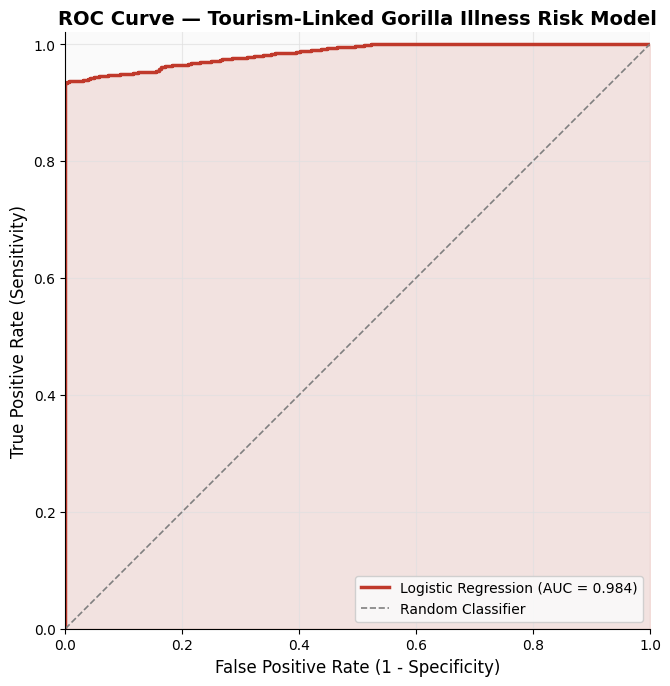

In [6]:
# ── Test set evaluation ────────────────────────────────────────────────────────
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

print(f'Test AUC: {auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Non-tourism', 'Tourism-attributed']))

# Plot ROC curve
fig, ax = plot_roc_curve(fpr, tpr, auc, figsize=(7, 7))
save_fig(fig, '06_roc_curve.png', str(FIG_DIR) + '/')
plt.show()

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/06_confusion_matrix.png


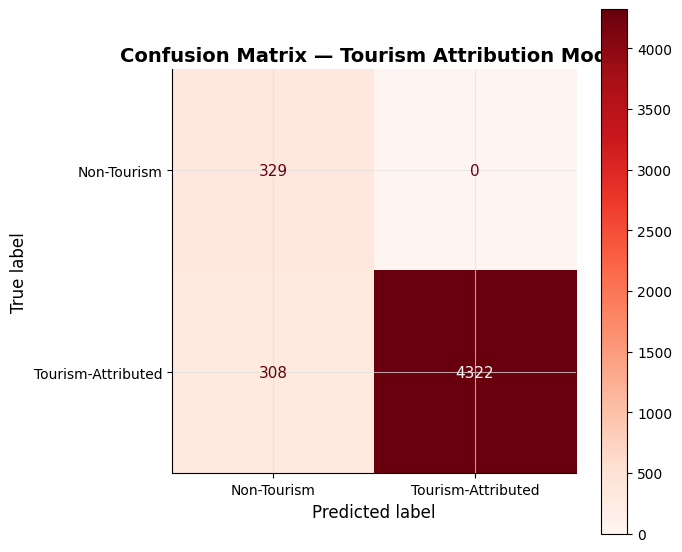

In [7]:
# ── Confusion matrix ───────────────────────────────────────────────────────────
set_style()
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Non-Tourism', 'Tourism-Attributed']
)
disp.plot(ax=ax, colorbar=True, cmap='Reds')
ax.set_title('Confusion Matrix — Tourism Attribution Model')
plt.tight_layout()
save_fig(fig, '06_confusion_matrix.png', str(FIG_DIR) + '/')
plt.show()

## Cell 7 — Feature Importance (Odds Ratios)

In [8]:
# ── Extract coefficients as odds ratios ───────────────────────────────────────
clf = pipeline.named_steps['clf']
scaler = pipeline.named_steps['scaler']

coefs = clf.coef_[0]
odds_ratios = np.exp(coefs)

coef_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coefficient': coefs,
    'odds_ratio': odds_ratios,
    'abs_coef': np.abs(coefs),
}).sort_values('abs_coef', ascending=False)

# 95% CI via bootstrapping (approximation without statsmodels)
coef_df['or_lower'] = np.exp(coefs - 1.96 * coefs.std())
coef_df['or_upper'] = np.exp(coefs + 1.96 * coefs.std())

print('=== TOP 15 FEATURES (by absolute coefficient) ===')
print(coef_df.head(15)[['feature', 'coefficient', 'odds_ratio', 'or_lower', 'or_upper']]
      .round(4).to_string(index=False))

=== TOP 15 FEATURES (by absolute coefficient) ===
                 feature  coefficient  odds_ratio  or_lower     or_upper
n_sym_tourists_in_window      12.7347 339304.7195 1867.1679 6.165899e+07
          group_id_Pablo       0.1820      1.1996    0.0056 1.860151e+02
        annual_mask_rate      -0.1590      0.8530    0.0059 1.942015e+02
       group_id_Ntambara       0.1533      1.1657    0.0047 1.550083e+02
         season_wet_long      -0.1427      0.8670    0.0055 1.816984e+02
   age_category_subadult      -0.1193      0.8876    0.0061 2.022664e+02
 age_category_adult_male       0.1188      1.1262    0.0052 1.731687e+02
           group_id_Susa       0.1137      1.1204    0.0052 1.731386e+02
            humidity_pct       0.1071      1.1131    0.0062 2.046459e+02
        group_id_Umubano       0.0936      1.0981    0.0051 1.687309e+02
          group_id_Hirwa      -0.0771      0.9258    0.0055 1.808234e+02
     age_category_infant      -0.0742      0.9285    0.0052 1.709321e+02
 

  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/06_feature_importance.png


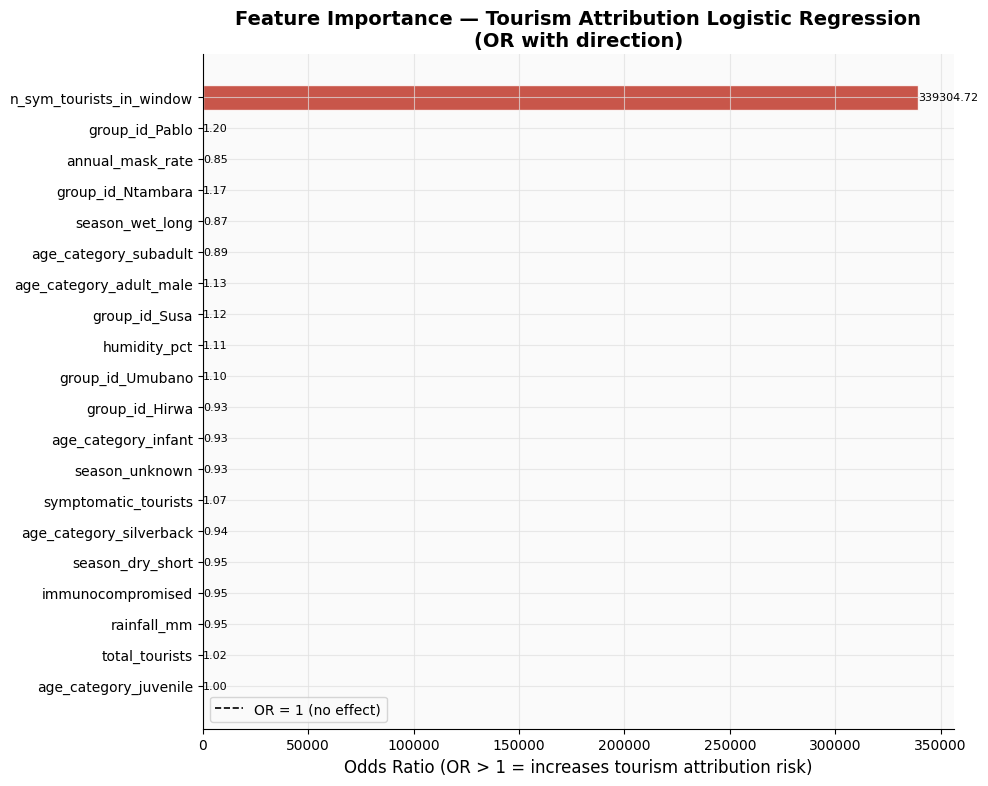

In [9]:
# ── Feature importance plot ────────────────────────────────────────────────────
set_style()
top_n = min(20, len(coef_df))
top_features = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#C0392B' if or_ > 1 else '#27AE60' for or_ in top_features['odds_ratio']]
bars = ax.barh(
    top_features['feature'],
    top_features['odds_ratio'],
    color=colors, alpha=0.85, edgecolor='white'
)
ax.axvline(x=1.0, color='black', linestyle='--', linewidth=1.2, label='OR = 1 (no effect)')
ax.set_xlabel('Odds Ratio (OR > 1 = increases tourism attribution risk)')
ax.set_title('Feature Importance — Tourism Attribution Logistic Regression\n(OR with direction)')
ax.invert_yaxis()
ax.legend()

# Add OR values
for bar, or_val in zip(bars, top_features['odds_ratio']):
    ax.text(
        or_val + 0.01, bar.get_y() + bar.get_height() / 2,
        f'{or_val:.2f}', va='center', fontsize=8
    )

plt.tight_layout()
save_fig(fig, '06_feature_importance.png', str(FIG_DIR) + '/')
plt.show()

## Cell 8 — Policy Scenario Simulations

=== POLICY SCENARIO SIMULATIONS ===
(Probability that a gorilla illness event is tourism-attributed)

Baseline (current)                                 P(tourism-attributed) = 1.0000 (100.0%)
Universal masking                                  P(tourism-attributed) = 1.0000 (100.0%)
Strict pre-screening (−80% symptomatic)            P(tourism-attributed) = 1.0000 (100.0%)
Combined: masking + strict screening               P(tourism-attributed) = 1.0000 (100.0%)
  → Saved: C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\figures/06_policy_scenarios.png


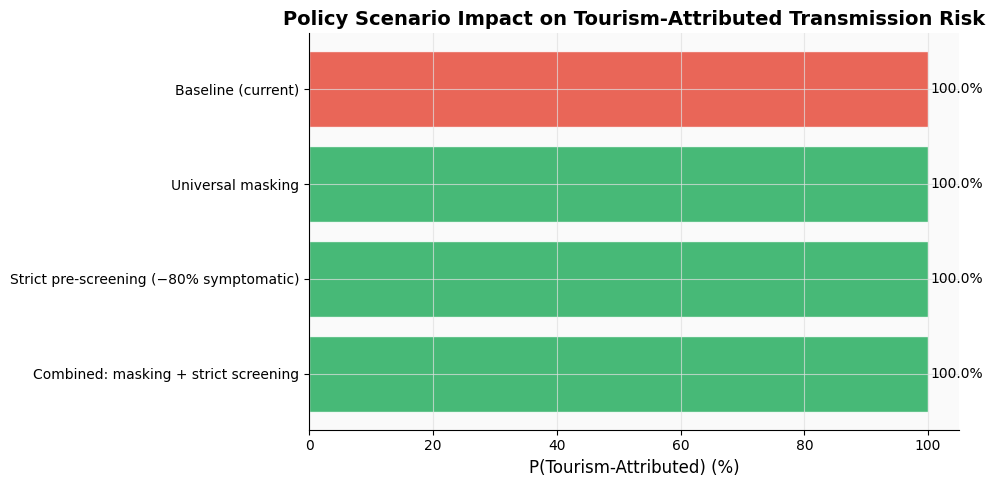

In [10]:
# ── Simulate policy interventions ─────────────────────────────────────────────
# Create a baseline scenario from median test set values
baseline = pd.DataFrame([X_test.mean(axis=0)], columns=FEATURE_COLS)

scenarios = {
    'Baseline (current)': baseline.copy(),
}

# Scenario: Universal masking (mask_rate → 1.0)
if 'annual_mask_rate' in FEATURE_COLS:
    mask_idx = FEATURE_COLS.index('annual_mask_rate')
    scen_mask = baseline.copy()
    scen_mask.iloc[0, mask_idx] = 1.0
    scenarios['Universal masking'] = scen_mask

# Scenario: Reduce symptomatic tourists by 80% (strict pre-screening)
if 'symptomatic_tourists' in FEATURE_COLS:
    sym_idx = FEATURE_COLS.index('symptomatic_tourists')
    scen_screen = baseline.copy()
    scen_screen.iloc[0, sym_idx] *= 0.20
    scenarios['Strict pre-screening (−80% symptomatic)'] = scen_screen

# Scenario: Combined interventions
if 'annual_mask_rate' in FEATURE_COLS and 'symptomatic_tourists' in FEATURE_COLS:
    scen_combined = baseline.copy()
    scen_combined.iloc[0, mask_idx] = 1.0
    scen_combined.iloc[0, sym_idx] *= 0.20
    scenarios['Combined: masking + strict screening'] = scen_combined

# Predict probabilities
print('=== POLICY SCENARIO SIMULATIONS ===')
print('(Probability that a gorilla illness event is tourism-attributed)')
print()

scenario_results = []
for name, scenario in scenarios.items():
    prob = pipeline.predict_proba(scenario.values)[0, 1]
    print(f'{name:<50} P(tourism-attributed) = {prob:.4f} ({prob*100:.1f}%)')
    scenario_results.append({'scenario': name, 'prob_tourism_attributed': prob})

scen_df = pd.DataFrame(scenario_results)

# Plot
set_style()
fig, ax = plt.subplots(figsize=(10, 5))
sc_colors = ['#E74C3C' if i == 0 else '#27AE60' for i in range(len(scen_df))]
ax.barh(scen_df['scenario'], scen_df['prob_tourism_attributed'] * 100,
        color=sc_colors, alpha=0.85, edgecolor='white')
ax.set_xlabel('P(Tourism-Attributed) (%)')
ax.set_title('Policy Scenario Impact on Tourism-Attributed Transmission Risk')
ax.invert_yaxis()
for i, (_, row) in enumerate(scen_df.iterrows()):
    ax.text(row['prob_tourism_attributed']*100 + 0.3, i,
            f"{row['prob_tourism_attributed']*100:.1f}%", va='center', fontsize=10)
plt.tight_layout()
save_fig(fig, '06_policy_scenarios.png', str(FIG_DIR) + '/')
plt.show()

## Cell 9 — Save Model Results

In [11]:
coef_df.to_csv(RPT_DIR / 'model_coefficients.csv', index=False)
scen_df.to_csv(RPT_DIR / 'policy_scenario_results.csv', index=False)

model_summary = {
    'model_type': 'Logistic Regression (sklearn)',
    'regularization': 'L2, C=1.0',
    'class_weight': 'balanced',
    'n_features': len(FEATURE_COLS),
    'n_train': int(X_train.shape[0]),
    'n_test': int(X_test.shape[0]),
    'test_auc': round(float(auc), 4),
    'cv_auc_mean': round(float(cv_scores.mean()), 4),
    'cv_auc_std': round(float(cv_scores.std()), 4),
}
pd.Series(model_summary).to_csv(RPT_DIR / 'model_summary.csv', header=['value'])

print('=== FILES SAVED ===')
for f in ['model_coefficients.csv', 'policy_scenario_results.csv', 'model_summary.csv']:
    print(f'  {RPT_DIR / f}')

print('\n✅ Notebook 06 complete. Proceed to 07_final_dashboard.ipynb')

=== FILES SAVED ===
  C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\reports\model_coefficients.csv
  C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\reports\policy_scenario_results.csv
  C:\Users\User\Desktop\gorilla-zoonotic-analysis\outputs\reports\model_summary.csv

✅ Notebook 06 complete. Proceed to 07_final_dashboard.ipynb
